<a href="https://colab.research.google.com/github/DenizhanOngun/Sentiment-Analysis---Recurrent-Architectures-vs.-Embeddings/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Environment Setup & Library Imports

# Install necessary libraries for dataset handling and transformers
# Note: 'torchtext' is excluded due to deprecation/incompatibility issues.
!pip install datasets transformers scikit-learn

import torch
import torch.nn as nn
import numpy as np
import time
import os
from datasets import load_dataset
from transformers import DistilBertTokenizer, DistilBertModel
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import f1_score, accuracy_score

# Device Configuration: Check for CUDA (GPU) availability for accelerated training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computational Device: {device}")

Computational Device: cuda


In [ ]:
# Cell 2: Data Preparation & Embedding Initialization

# 1. Download and Extract GloVe Embeddings (Manual Method for Stability)
# We utilize pre-trained GloVe 6B 300d vectors as the static embedding baseline.
if not os.path.exists('glove.6B.zip'):
    print("Downloading GloVe embeddings (approx. 800MB)...")
    !wget http://nlp.stanford.edu/data/glove.6B.zip
    !unzip -q glove.6B.zip
    print("Download complete.")

# 2. Helper Function to Load GloVe Vectors
def load_glove_manual(dim=300):
    """
    Parses the GloVe text file and constructs a dictionary mapping words to vectors.
    Initializes special tokens <pad> (zero vector) and <unk> (random vector).
    """
    print("Loading GloVe vectors into memory...")
    embeddings_index = {}

    # Read the GloVe file
    with open(f"glove.6B.{dim}d.txt", encoding='utf8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs

    # Initialize vocabulary with special tokens
    # Index 0: <pad>, Index 1: <unk>
    stoi = {'<pad>': 0, '<unk>': 1}
    # <pad> is initialized as a zero vector; <unk> as a random normal vector
    vectors = [np.zeros(dim), np.random.normal(scale=0.6, size=(dim,))]

    # Populate the vocabulary
    idx = 2
    for word, vector in embeddings_index.items():
        stoi[word] = idx
        vectors.append(vector)
        idx += 1

    return stoi, torch.tensor(np.array(vectors), dtype=torch.float32)

# Load GloVe (300d) into memory
glove_stoi, glove_vectors = load_glove_manual(dim=300)

# --- Custom Dataset Class ---
class UnifiedIMDbDataset(Dataset):
    """
    Custom Dataset class to handle both Static (GloVe) and Contextual (BERT) tokenization.
    Ensures a fixed sequence length of 450 tokens.
    """
    def __init__(self, data, tokenizer_type='glove', max_len=450):
        self.data = data
        self.tokenizer_type = tokenizer_type
        self.max_len = max_len

        # Initialize DistilBERT Tokenizer if contextual embedding is selected
        if tokenizer_type == 'bert':
            self.tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data[idx]['text']
        label = self.data[idx]['label']

        # Strategy A: GloVe Preprocessing
        if self.tokenizer_type == 'glove':
            # Basic Tokenization -> Index Mapping
            tokens = text.lower().split()
            token_ids = []
            for token in tokens:
                if token in glove_stoi:
                    token_ids.append(glove_stoi[token])
                else:
                    token_ids.append(glove_stoi['<unk>']) # Handle unknown words

            # Fixed Length Padding/Truncation (max_len=450)
            if len(token_ids) > self.max_len:
                token_ids = token_ids[:self.max_len]
            else:
                token_ids += [0] * (self.max_len - len(token_ids)) # Pad with 0

            # Return input_ids, label, and a dummy mask (not used for GloVe)
            return torch.tensor(token_ids), torch.tensor(label), torch.tensor(0)

        # Strategy B: BERT Preprocessing
        elif self.tokenizer_type == 'bert':
            encoding = self.tokenizer(
                text,
                padding='max_length',
                truncation=True,
                max_length=self.max_len,
                return_tensors='pt'
            )
            # Return input_ids, label, and attention_mask
            return encoding['input_ids'].squeeze(0), torch.tensor(label), encoding['attention_mask'].squeeze(0)

# Load Raw Data from Hugging Face
raw_dataset = load_dataset("imdb")
# Note: Data subsets will be defined in the main experiment loop.
train_data_raw = raw_dataset['train'].shuffle(seed=42).select(range(2000))
test_data_raw = raw_dataset['test'].shuffle(seed=42).select(range(500))

--2026-05-01 13:34:23--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-05-01 13:34:23--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-05-01 13:34:24--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
# Cell 3: Model Architecture (Fair Comparison)

class FairSequenceModel(nn.Module):
    """
    A unified sequence classification architecture designed to compare
    Static (GloVe) and Contextual (BERT) embeddings under a controlled environment.

    Key Feature: Includes a 'Projection Layer' to map different embedding dimensions
    (300 for GloVe, 768 for BERT) to a fixed latent dimension (256), ensuring
    that the downstream RNNs have an identical number of parameters.
    """
    def __init__(self, embedding_type, rnn_type, hidden_dim=128, output_dim=2, n_layers=2, bidirectional=True, dropout=0.3,
                 common_input_dim=256, glove_weights=None):
        super().__init__()

        self.embedding_type = embedding_type
        self.rnn_type = rnn_type

        # --- 1. Embedding Layer & Linear Projection ---
        if embedding_type == 'glove':
            # Initialize with pre-loaded GloVe vectors and freeze them (Static)
            self.embedding = nn.Embedding.from_pretrained(glove_weights, freeze=True)
            # Project 300d -> 256d
            self.projection = nn.Linear(300, common_input_dim)

        elif embedding_type == 'bert':
            # Load pre-trained DistilBERT
            self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
            # Freeze BERT parameters to use it strictly as a Feature Extractor
            for param in self.bert.parameters():
                param.requires_grad = False
            # Project 768d -> 256d
            self.projection = nn.Linear(768, common_input_dim)

        self.relu = nn.ReLU()
        self.dropout_layer = nn.Dropout(dropout)

        # --- 2. Recurrent Layer (Inductive Bias Component) ---
        # The input dimension is fixed to 'common_input_dim' (256) regardless of the embedding source.
        # This guarantees fair parameter count comparison between architectures.
        rnn_cls = nn.LSTM if rnn_type == 'LSTM' else nn.GRU
        self.rnn = rnn_cls(common_input_dim, hidden_dim, num_layers=n_layers,
                           bidirectional=bidirectional, dropout=dropout, batch_first=True)

        # --- 3. Classification Head ---
        # Handle bidirectional output concatenation (hidden_dim * 2)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)

    def forward(self, x, attention_mask=None):
        # Phase 1: Embedding Extraction
        if self.embedding_type == 'glove':
            embedded = self.embedding(x) # Shape: (Batch, Seq_Len, 300)
        else:
            # Contextual embeddings (DistilBERT)
            with torch.no_grad(): # Ensure no gradients flow back to BERT
                # Use last_hidden_state as the sequence representation
                embedded = self.bert(input_ids=x, attention_mask=attention_mask).last_hidden_state
                # Shape: (Batch, Seq_Len, 768)

        # Phase 2: Dimensionality Alignment (Projection)
        # Unified Shape: (Batch, Seq_Len, 256)
        projected = self.relu(self.projection(embedded))
        projected = self.dropout_layer(projected)

        # Phase 3: Sequence Modeling (RNN)
        if self.rnn_type == 'LSTM':
            output, (hidden, cell) = self.rnn(projected)
        else:
            output, hidden = self.rnn(projected)

        # Phase 4: Feature Aggregation
        # Concatenate the final hidden states from forward and backward directions
        if self.rnn.bidirectional:
            hidden_final = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden_final = hidden[-1,:,:]

        # Return logits for loss calculation and hidden_final for t-SNE visualization
        return self.fc(hidden_final), hidden_final

In [ ]:
# Cell 4: Training and Evaluation Engine

def train_and_evaluate(model, train_loader, test_loader, epochs=5):
    """
    Executes the training loop and evaluates the model on the test set.
    Tracks 'Convergence Efficiency' by measuring time per epoch.

    Args:
        epochs (int): Number of training passes (set to 5 for the final experiment).
    """
    # Initialize Optimizer (Adam) and Loss Function (Cross-Entropy)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    model = model.to(device)

    # Dictionary to store performance metrics and timing data
    history = {'loss': [], 'acc': [], 'f1': [], 'time': []}

    total_start = time.time()
    print(f"Starting training for {epochs} epochs...")

    for epoch in range(epochs):
        epoch_start = time.time()
        model.train() # Set model to training mode
        train_loss = 0

        # --- Training Phase ---
        for text, label, mask in train_loader:
            text, label, mask = text.to(device), label.to(device), mask.to(device)
            optimizer.zero_grad()

            # Handle attention mask: Required for BERT, ignored for GloVe
            mask_input = mask if model.embedding_type == 'bert' else None
            predictions, _ = model(text, mask_input)

            loss = criterion(predictions, label)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        epoch_time = time.time() - epoch_start

        # --- Validation Phase ---
        model.eval() # Set model to evaluation mode
        all_preds, all_labels = [], []

        with torch.no_grad():
            for text, label, mask in test_loader:
                text, label, mask = text.to(device), label.to(device), mask.to(device)
                mask_input = mask if model.embedding_type == 'bert' else None

                preds, _ = model(text, mask_input)

                # Store predictions and labels for metric calculation
                all_preds.extend(torch.argmax(preds, dim=1).cpu().numpy())
                all_labels.extend(label.cpu().numpy())

        # Calculate Metrics (Accuracy & Macro-F1)
        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro')

        # Log convergence efficiency (Time per Epoch)
        print(f"Epoch {epoch+1}/{epochs} | Duration: {epoch_time:.1f}s | Val Acc: {acc:.4f} | Val F1: {f1:.4f}")
        history['time'].append(epoch_time)
        history['acc'].append(acc)

    total_time = time.time() - total_start
    print(f"Training Complete. Total Time: {total_time:.1f}s")
    return history

Initiating Experiments... (Data will be recorded after each training session)

>>> Running Experiment: GLOVE + LSTM...
Starting training for 3 epochs...
Epoch 1/3 | Duration: 4.2s | Val Acc: 0.5560 | Val F1: 0.5519
Epoch 2/3 | Duration: 4.4s | Val Acc: 0.6500 | Val F1: 0.6481
Epoch 3/3 | Duration: 3.4s | Val Acc: 0.6400 | Val F1: 0.6377
Training Complete. Total Time: 14.1s
   > Extracting features for t-SNE visualization (GLOVE + LSTM)...

>>> Running Experiment: GLOVE + GRU...
Starting training for 3 epochs...
Epoch 1/3 | Duration: 3.2s | Val Acc: 0.5640 | Val F1: 0.5638
Epoch 2/3 | Duration: 3.5s | Val Acc: 0.6820 | Val F1: 0.6778
Epoch 3/3 | Duration: 2.5s | Val Acc: 0.7080 | Val F1: 0.7078
Training Complete. Total Time: 10.9s
   > Extracting features for t-SNE visualization (GLOVE + GRU)...

>>> Running Experiment: BERT + LSTM...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting training for 3 epochs...
Epoch 1/3 | Duration: 30.9s | Val Acc: 0.7580 | Val F1: 0.7571
Epoch 2/3 | Duration: 31.6s | Val Acc: 0.8140 | Val F1: 0.8140
Epoch 3/3 | Duration: 33.6s | Val Acc: 0.8280 | Val F1: 0.8279
Training Complete. Total Time: 118.7s
   > Extracting features for t-SNE visualization (BERT + LSTM)...

>>> Running Experiment: BERT + GRU...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting training for 3 epochs...
Epoch 1/3 | Duration: 31.9s | Val Acc: 0.7920 | Val F1: 0.7920
Epoch 2/3 | Duration: 32.8s | Val Acc: 0.8060 | Val F1: 0.8057
Epoch 3/3 | Duration: 33.0s | Val Acc: 0.8180 | Val F1: 0.8180
Training Complete. Total Time: 119.9s
   > Extracting features for t-SNE visualization (BERT + GRU)...

All experiments completed. Generating comparative plots...


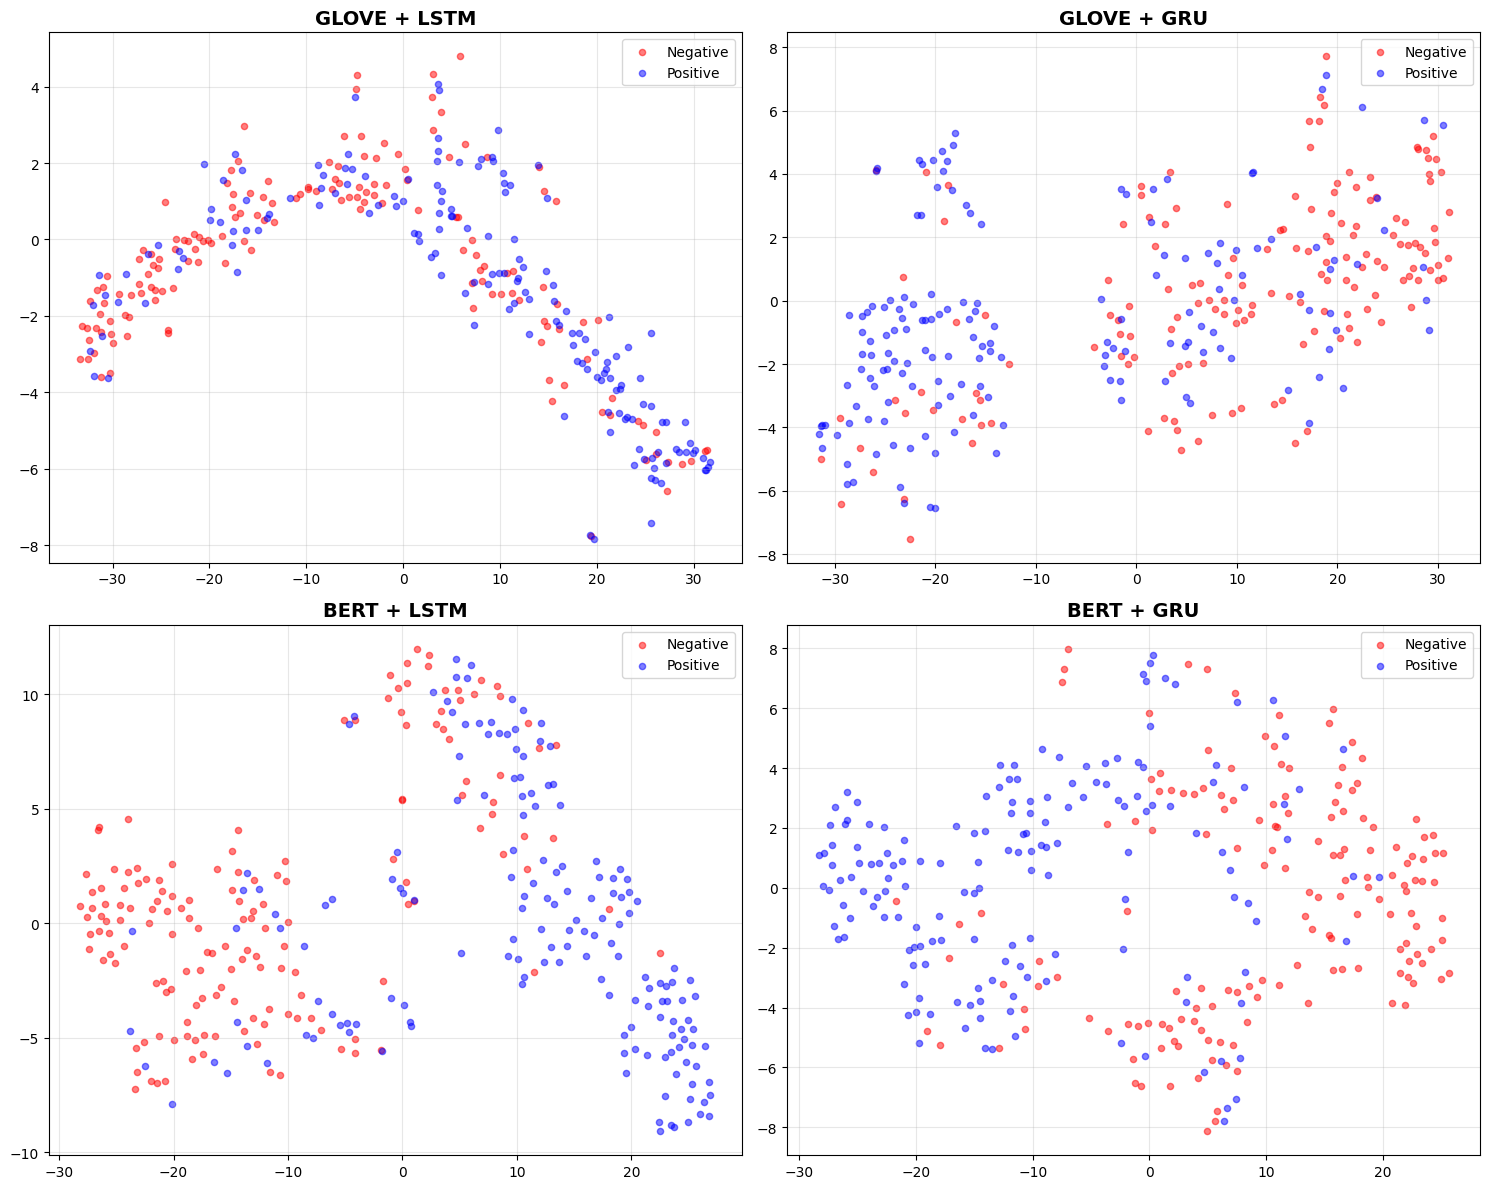

In [ ]:
# Cell 5: Main Experimental Loop & Visualization

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Define Experiment Configurations (Embedding, Architecture)
experiments = [
    ('glove', 'LSTM'),
    ('glove', 'GRU'),
    ('bert', 'LSTM'),
    ('bert', 'GRU')
]

# Dictionaries to store training history and visualization data
plot_data = {}
results = {}

BATCH_SIZE = 32

print("Initiating Experiments... (Data will be recorded after each training session)")

for emb_type, rnn_type in experiments:
    exp_name = f"{emb_type.upper()} + {rnn_type}"
    print(f"\n>>> Running Experiment: {exp_name}...")

    # 1. Prepare Dataset and DataLoader
    # Using the raw splits defined in Cell 2
    train_ds = UnifiedIMDbDataset(train_data_raw, tokenizer_type=emb_type)
    test_ds = UnifiedIMDbDataset(test_data_raw, tokenizer_type=emb_type)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE)

    # 2. Initialize the FairSequenceModel
    model = FairSequenceModel(
        embedding_type=emb_type,
        rnn_type=rnn_type,
        glove_weights=glove_vectors if emb_type == 'glove' else None
    )

    # 3. Execute Training
    # Training for 3 epochs as per the initial low-resource setup
    hist = train_and_evaluate(model, train_dl, test_dl, epochs=3)
    results[exp_name] = hist

    # 4. Extract Latent Representations for t-SNE
    print(f"   > Extracting features for t-SNE visualization ({exp_name})...")
    model.eval()
    vectors = []
    labels = []
    count = 0

    with torch.no_grad():
        for text, label, mask in test_dl:
            text, label, mask = text.to(device), label.to(device), mask.to(device)
            mask_input = mask if model.embedding_type == 'bert' else None

            # Forward pass to get hidden states (we only need the second return value)
            _, hidden = model(text, mask_input)

            vectors.append(hidden.cpu().numpy())
            labels.append(label.cpu().numpy())
            count += len(label)
            if count >= 300: break # Limit points to 300 for faster visualization

    vectors = np.concatenate(vectors, axis=0)
    labels = np.concatenate(labels, axis=0)

    # 5. Compute t-SNE (Project 256d -> 2d)
    # Perplexity=30 is standard for this dataset size
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    vectors_2d = tsne.fit_transform(vectors)

    # Store for plotting
    plot_data[exp_name] = (vectors_2d, labels)

print("\nAll experiments completed. Generating comparative plots...")

# --- Visualization: 2x2 Grid ---
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (name, data) in enumerate(plot_data.items()):
    vecs, lbls = data
    ax = axes[i]

    # Scatter Plot: Negative (Red) vs Positive (Blue)
    ax.scatter(vecs[lbls==0, 0], vecs[lbls==0, 1], c='red', label='Negative', alpha=0.5, s=20)
    ax.scatter(vecs[lbls==1, 0], vecs[lbls==1, 1], c='blue', label='Positive', alpha=0.5, s=20)

    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

--- NEW EXPERIMENTAL SETTINGS ---
Data Size: 15000
Batch Size: 64
Epochs: 5
This process may take approximately 15-20 minutes, please wait...


>>> Training: GLOVE + LSTM...
Starting training for 5 epochs...
Epoch 1/5 | Duration: 19.0s | Val Acc: 0.6070 | Val F1: 0.5819
Epoch 2/5 | Duration: 19.5s | Val Acc: 0.5115 | Val F1: 0.3991
Epoch 3/5 | Duration: 19.0s | Val Acc: 0.7990 | Val F1: 0.7985
Epoch 4/5 | Duration: 19.4s | Val Acc: 0.8420 | Val F1: 0.8413
Epoch 5/5 | Duration: 18.9s | Val Acc: 0.8445 | Val F1: 0.8429
Training Complete. Total Time: 101.9s
   > Collecting t-SNE data (GLOVE + LSTM)...

>>> Training: GLOVE + GRU...
Starting training for 5 epochs...
Epoch 1/5 | Duration: 14.8s | Val Acc: 0.7325 | Val F1: 0.7236
Epoch 2/5 | Duration: 14.9s | Val Acc: 0.7565 | Val F1: 0.7523
Epoch 3/5 | Duration: 14.8s | Val Acc: 0.8390 | Val F1: 0.8377
Epoch 4/5 | Duration: 14.8s | Val Acc: 0.8530 | Val F1: 0.8522
Epoch 5/5 | Duration: 14.9s | Val Acc: 0.8730 | Val F1: 0.8730
Training Comple

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting training for 5 epochs...
Epoch 1/5 | Duration: 233.7s | Val Acc: 0.8485 | Val F1: 0.8483
Epoch 2/5 | Duration: 232.5s | Val Acc: 0.8640 | Val F1: 0.8637
Epoch 3/5 | Duration: 233.3s | Val Acc: 0.8700 | Val F1: 0.8697
Epoch 4/5 | Duration: 232.6s | Val Acc: 0.8660 | Val F1: 0.8652
Epoch 5/5 | Duration: 232.5s | Val Acc: 0.8630 | Val F1: 0.8630
Training Complete. Total Time: 1309.6s
   > Collecting t-SNE data (BERT + LSTM)...

>>> Training: BERT + GRU...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting training for 5 epochs...
Epoch 1/5 | Duration: 228.2s | Val Acc: 0.8530 | Val F1: 0.8527
Epoch 2/5 | Duration: 228.7s | Val Acc: 0.8835 | Val F1: 0.8834
Epoch 3/5 | Duration: 229.1s | Val Acc: 0.8920 | Val F1: 0.8918
Epoch 4/5 | Duration: 228.2s | Val Acc: 0.8980 | Val F1: 0.8977
Epoch 5/5 | Duration: 228.0s | Val Acc: 0.8985 | Val F1: 0.8983
Training Complete. Total Time: 1286.3s
   > Collecting t-SNE data (BERT + GRU)...

Generating Comparative Plots...


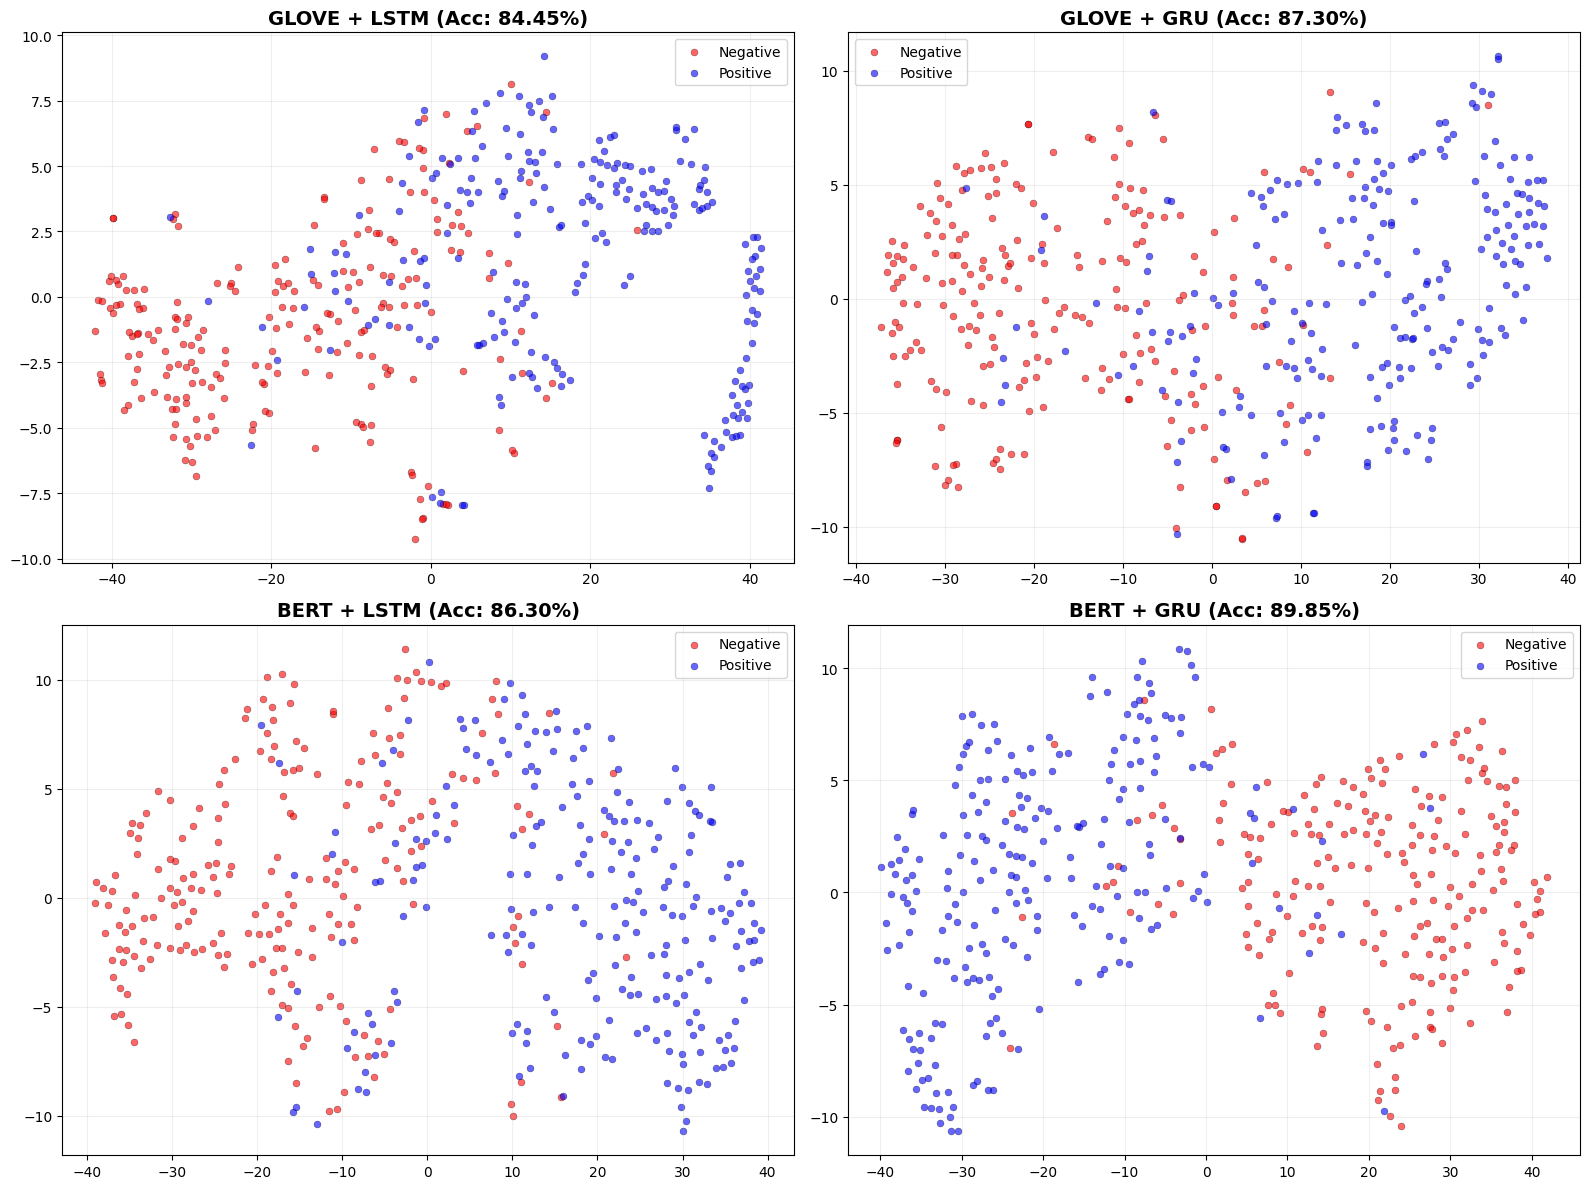

In [ ]:
# Cell 6: High-Performance Comparative Experiment (Scale-Up)

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# --- CRITICAL HYPERPARAMETERS ---
# Scaling up the dataset from 2,000 to 15,000 samples.
# This is essential to allow Static Embeddings (GloVe) to escape underfitting.
TRAIN_SIZE = 15000
TEST_SIZE = 2000
BATCH_SIZE = 64     # Increased batch size for faster iteration
EPOCHS = 5

print(f"--- NEW EXPERIMENTAL SETTINGS ---\nData Size: {TRAIN_SIZE}\nBatch Size: {BATCH_SIZE}\nEpochs: {EPOCHS}")
print("This process may take approximately 15-20 minutes, please wait...\n")

# Prepare the Extended Dataset
# Resampling from the raw dataset with the new TRAIN_SIZE
train_data_full = raw_dataset['train'].shuffle(seed=42).select(range(TRAIN_SIZE))
test_data_full = raw_dataset['test'].shuffle(seed=42).select(range(TEST_SIZE))

experiments = [
    ('glove', 'LSTM'),
    ('glove', 'GRU'),
    ('bert', 'LSTM'), # Retraining BERT on the larger dataset for a fair benchmark
    ('bert', 'GRU')
]

plot_data = {}
results = {}

for emb_type, rnn_type in experiments:
    exp_name = f"{emb_type.upper()} + {rnn_type}"
    print(f"\n>>> Training: {exp_name}...")

    # 1. Initialize Dataset & Loader (With Extended Data)
    train_ds = UnifiedIMDbDataset(train_data_full, tokenizer_type=emb_type)
    test_ds = UnifiedIMDbDataset(test_data_full, tokenizer_type=emb_type)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE)

    # 2. Initialize Model
    model = FairSequenceModel(
        embedding_type=emb_type,
        rnn_type=rnn_type,
        glove_weights=glove_vectors if emb_type == 'glove' else None
    ).to(device)

    # 3. Execute Training (5 Epochs)
    hist = train_and_evaluate(model, train_dl, test_dl, epochs=EPOCHS)
    results[exp_name] = hist

    # 4. Extract Latent Features for t-SNE
    print(f"   > Collecting t-SNE data ({exp_name})...")
    model.eval()
    vectors, labels = [], []
    count = 0

    with torch.no_grad():
        for text, label, mask in test_dl:
            text, label, mask = text.to(device), label.to(device), mask.to(device)
            mask_input = mask if model.embedding_type == 'bert' else None
            _, hidden = model(text, mask_input)

            vectors.append(hidden.cpu().numpy())
            labels.append(label.cpu().numpy())
            count += len(label)
            if count >= 400: break # Increased sample size (400) for denser visualization

    vectors = np.concatenate(vectors, axis=0)
    labels = np.concatenate(labels, axis=0)

    # Compute t-SNE projections
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    plot_data[exp_name] = (tsne.fit_transform(vectors), labels)

print("\nGenerating Comparative Plots...")

# --- PLOTTING ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (name, data) in enumerate(plot_data.items()):
    vecs, lbls = data
    ax = axes[i]

    # Scatter Plot with transparency and edge colors for better visibility
    ax.scatter(vecs[lbls==0, 0], vecs[lbls==0, 1], c='red', label='Negative', alpha=0.6, s=25, edgecolors='k', linewidth=0.3)
    ax.scatter(vecs[lbls==1, 0], vecs[lbls==1, 1], c='blue', label='Positive', alpha=0.6, s=25, edgecolors='k', linewidth=0.3)

    # Display final Accuracy in the title for immediate comparison
    final_acc = results[name]['acc'][-1]
    ax.set_title(f"{name} (Acc: {final_acc:.2%})", fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()